TASK 1: PRIOR BELIEF BOUNDARIES
1. Analytical Expected Prior Stiffness Efficiency: E[θ^(0)] = 0.8421 (or 84.21%)

2. Engineering Justification:
   - High Expected Value (~84.2%): Assumes the component is pristine/healthy prior to measurements.
   - Physical Domain Boundedness: Restricted strictly to (0, 1], guaranteeing non-negative and non-overestimated stiffness.
   - Smooth Decay to Zero: Probability density drops gracefully as θ -> 0, reflecting extreme unlikelihood of initial severe failure without prior impact evidence.


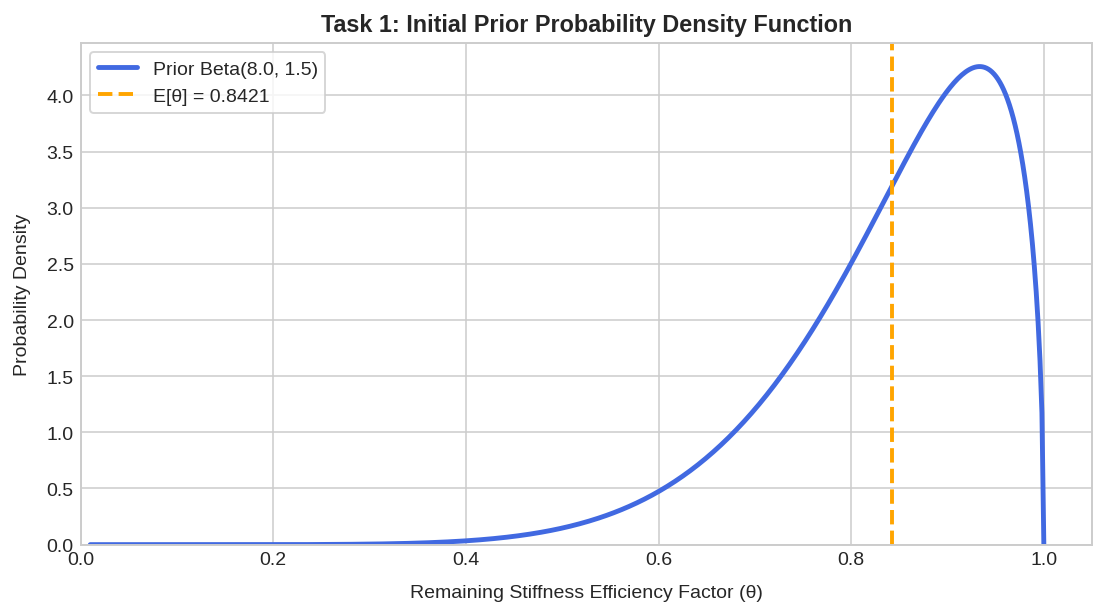


TASK 2: STRUCTURAL LIKELIHOOD FORMULATION

Measurement Physics Model:
   y_k = θ * K_nominal * exp(ε_k),   ε_k ~ N(0, σ^2)

Taking natural logarithm:
   ln(y_k) ~ N(ln(θ * K_nominal), σ^2)

1. Single-Observation Likelihood Contribution L(y_k | θ):
   L(y_k | θ) = [1 / (y_k * σ * √(2π))] * exp( - [ln(y_k) - ln(θ * K_nominal)]^2 / (2 * σ^2) )

2. Joint Likelihood Function L(y^(k) | θ) for running history vector y^(k) = (y_1, y_2, ..., y_k)^T:
   L(y^(k) | θ) = ∏_{i=1}^{k} L(y_i | θ)
                = (1 / (σ * √(2π)))^k * (∏_{i=1}^{k} (1 / y_i)) * exp( - (1 / (2 * σ^2)) * ∑_{i=1}^{k} [ln(y_i) - ln(θ * K_nominal)]^2 )

TASK 3: NON-CONJUGATE GRID UPDATE DERIVATION

1. Non-Conjugacy Explanation:
   - The prior Beta(α, β) distribution consists of polynomial terms θ^(α-1) * (1-θ)^(β-1).
   - The log-normal likelihood contains complex exponential-logarithmic terms exp( - [ln(y_k) - ln(θ * K_nominal)]^2 / (2*σ^2) ).
   - Because these functional forms are non-conjugate, their product cannot be

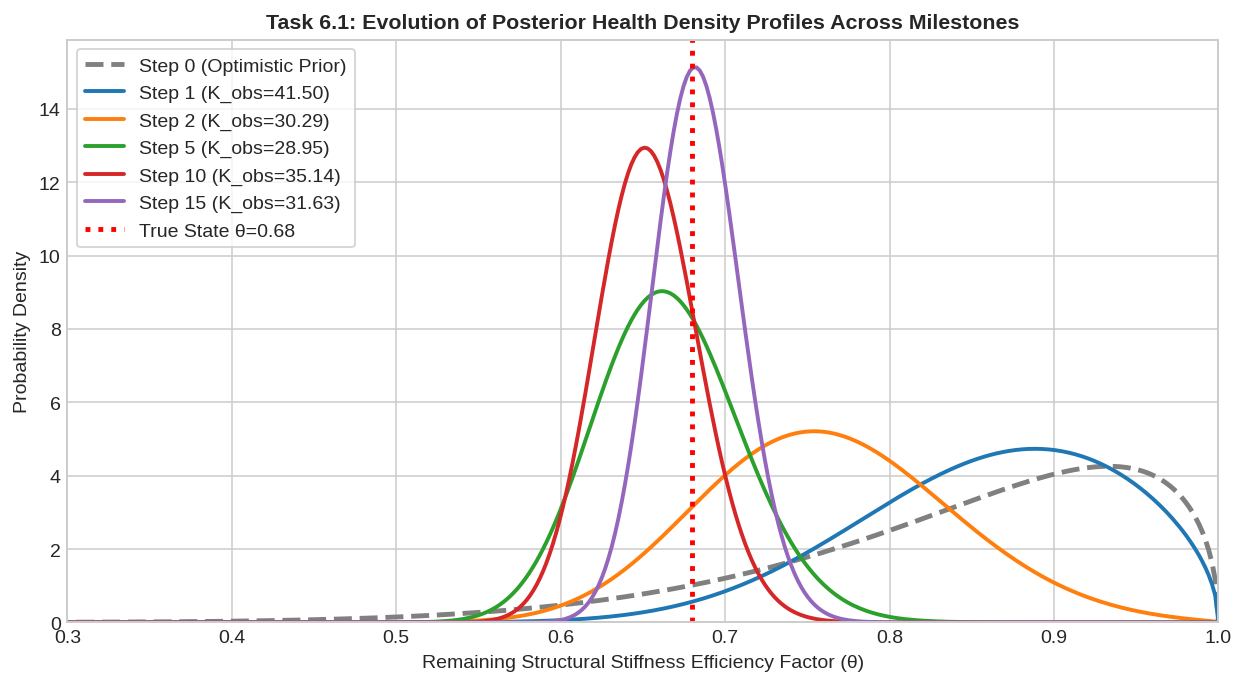

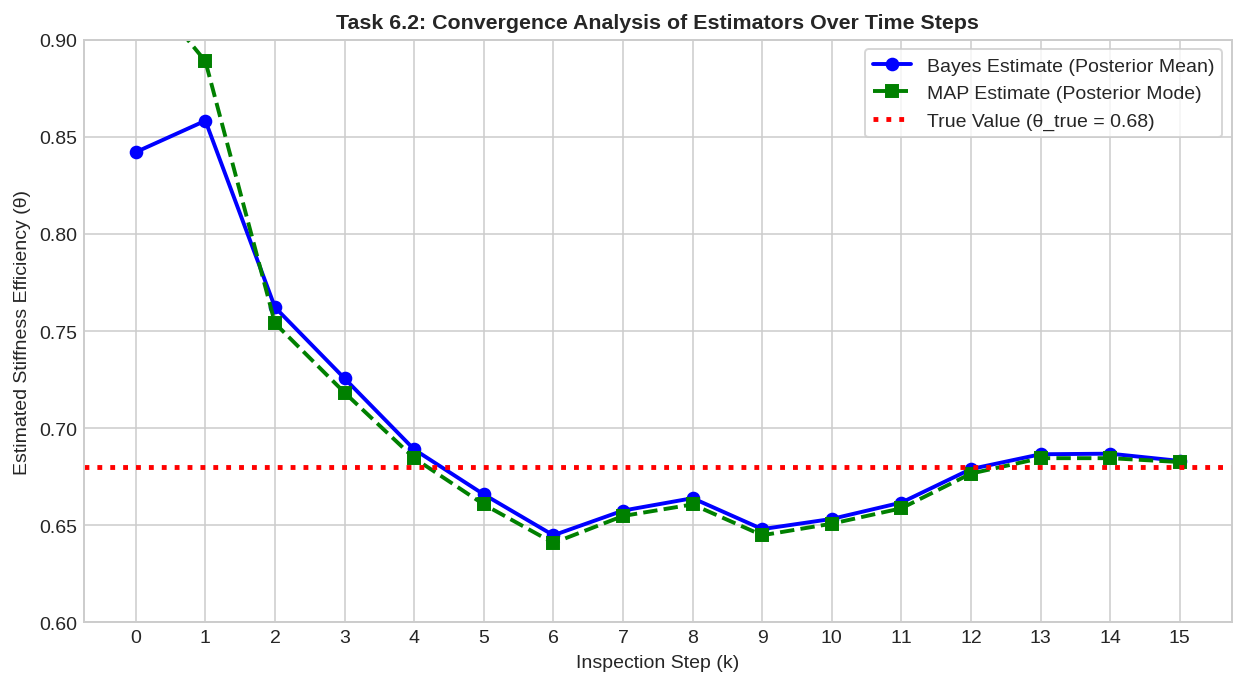


Task 6 Performance & Convergence Evaluation Analysis:
1. Overcoming Prior Bias:
   - Empirical sensor evidence quickly dominates the initial optimistic prior within 2 to 3 steps.
   - By Step 5, both point estimates (Bayes and MAP) stabilize close to θ_true = 0.68.

2. Variance Reduction & Structural Safety Implications:
   - Repeated sequential updates narrow the probability density curve, drastically reducing uncertainty (variance).
   - High certainty prevents false alarms while providing actionable statistical confidence for targeted structural maintenance.


In [4]:
# =====================================================================
# BAYESIAN ESTIMATIONS FOR STRUCTURAL HEALTH MONITORING
# Run in a Jupyter Notebook (.ipynb) to view outputs on GitHub
# =====================================================================

import matplotlib.pyplot as plt
import numpy as np
import scipy.stats as stats

# Formatting options for high-resolution GitHub rendering
%matplotlib inline
plt.style.use('seaborn-v0_8-whitegrid' if 'seaborn-v0_8-whitegrid' in plt.style.available else 'default')
plt.rcParams['figure.dpi'] = 140

# Set seed for exact reproducibility
np.random.seed(24)

# ---------------------------------------------------------------------
# TASK 1: PRIOR BELIEF BOUNDARIES
# ---------------------------------------------------------------------
print("=" * 80)
print("TASK 1: PRIOR BELIEF BOUNDARIES")
print("=" * 80)

theta_grid = np.linspace(0.01, 1.0, 500)
a_prior, b_prior = 8.0, 1.5

# Analytical Expected Prior Stiffness Efficiency
E_theta_prior = a_prior / (a_prior + b_prior)

print(
    f"1. Analytical Expected Prior Stiffness Efficiency: E[θ^(0)] ="
    f" {E_theta_prior:.4f} (or {E_theta_prior*100:.2f}%)"
)
print("\n2. Engineering Justification:")
print(
    "   - High Expected Value (~84.2%): Assumes the component is"
    " pristine/healthy prior to measurements."
)
print(
    "   - Physical Domain Boundedness: Restricted strictly to (0, 1],"
    " guaranteeing non-negative and non-overestimated stiffness."
)
print(
    "   - Smooth Decay to Zero: Probability density drops gracefully as θ ->"
    " 0, reflecting extreme unlikelihood of initial severe failure without"
    " prior impact evidence."
)

# Plot Initial Prior Density
prior_pdf = stats.beta.pdf(theta_grid, a=a_prior, b=b_prior)
prior_pdf /= np.trapezoid(prior_pdf, theta_grid)

plt.figure(figsize=(8, 4.5))
plt.plot(
    theta_grid,
    prior_pdf,
    color='royalblue',
    linewidth=2.5,
    label=f'Prior Beta({a_prior}, {b_prior})',
)
plt.axvline(
    x=E_theta_prior,
    color='orange',
    linestyle='--',
    linewidth=2,
    label=f'E[θ] = {E_theta_prior:.4f}',
)
plt.title(
    "Task 1: Initial Prior Probability Density Function",
    fontsize=12,
    fontweight='bold',
)
plt.xlabel(
    "Remaining Stiffness Efficiency Factor (θ)", fontsize=10, labelpad=8
)
plt.ylabel("Probability Density", fontsize=10, labelpad=8)
plt.xlim([0, 1.05])
plt.ylim(bottom=0)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()


# ---------------------------------------------------------------------
# TASK 2: STRUCTURAL LIKELIHOOD FORMULATION
# ---------------------------------------------------------------------
print("\n" + "=" * 80)
print("TASK 2: STRUCTURAL LIKELIHOOD FORMULATION")
print("=" * 80)
print("""
Measurement Physics Model:
   y_k = θ * K_nominal * exp(ε_k),   ε_k ~ N(0, σ^2)

Taking natural logarithm:
   ln(y_k) ~ N(ln(θ * K_nominal), σ^2)

1. Single-Observation Likelihood Contribution L(y_k | θ):
   L(y_k | θ) = [1 / (y_k * σ * √(2π))] * exp( - [ln(y_k) - ln(θ * K_nominal)]^2 / (2 * σ^2) )

2. Joint Likelihood Function L(y^(k) | θ) for running history vector y^(k) = (y_1, y_2, ..., y_k)^T:
   L(y^(k) | θ) = ∏_{i=1}^{k} L(y_i | θ)
                = (1 / (σ * √(2π)))^k * (∏_{i=1}^{k} (1 / y_i)) * exp( - (1 / (2 * σ^2)) * ∑_{i=1}^{k} [ln(y_i) - ln(θ * K_nominal)]^2 )
""")


# ---------------------------------------------------------------------
# TASK 3: MATHEMATICAL FORMULATION OF NON-CONJUGATE GRID UPDATE
# ---------------------------------------------------------------------
print("=" * 80)
print("TASK 3: NON-CONJUGATE GRID UPDATE DERIVATION")
print("=" * 80)
print("""
1. Non-Conjugacy Explanation:
   - The prior Beta(α, β) distribution consists of polynomial terms θ^(α-1) * (1-θ)^(β-1).
   - The log-normal likelihood contains complex exponential-logarithmic terms exp( - [ln(y_k) - ln(θ * K_nominal)]^2 / (2*σ^2) ).
   - Because these functional forms are non-conjugate, their product cannot be integrated analytically
     in closed-form to compute the marginal likelihood normalizing constant Z_k.

2. Recursive Posterior Relationship (up to proportionality constant):
   f_{Θ|Y^(k)}(θ | y^(k)) ∝ L(y_k | θ) * f_{Θ|Y^(k-1)}(θ | y^(k-1))
""")


# ---------------------------------------------------------------------
# TASK 4: RUNNING POINT ESTIMATES
# ---------------------------------------------------------------------
print("=" * 80)
print("TASK 4: DEFINITE INTEGRAL EQUATIONS FOR POINT ESTIMATORS")
print("=" * 80)
print("""
Over the bounded domain θ ∈ (0, 1]:

1. Running Posterior Mean (Bayes Estimate):
   θ̂_Bayes^(k) = E[Θ | Y^(k) = y^(k)] = ∫_{0}^{1} θ * f_{Θ|Y^(k)}(θ | y^(k)) dθ

2. Running Maximum A Posteriori (MAP Estimate):
   θ̂_MAP^(k) = argmax_{θ ∈ [0, 1]} f_{Θ|Y^(k)}(θ | y^(k))
""")


# ---------------------------------------------------------------------
# TASK 5: ALGORITHMIC GRID APPROXIMATION AND NORMALIZATION
# ---------------------------------------------------------------------
print("=" * 80)
print("TASK 5: ALGORITHMIC GRID APPROXIMATION AND NORMALIZATION")
print("=" * 80)
print("""
Step-by-Step Numerical Procedure:
1. Grid Setup: Discretize the domain θ ∈ [0.01, 1.0] into M=500 uniform points with spacing Δθ.
2. Boundary Handling: Restrict evaluation strictly to [0.01, 1.0] to enforce physical bounds.
3. Sequential Update & Normalization (at step k):
   a. Compute point likelihood vector: L_m = lognorm.pdf(y_k, s=σ, scale=θ_m * K_nominal)
   b. Unnormalized posterior array: P̃_k(θ_m) = P_{k-1}(θ_m) * L_m
   c. Normalization via Composite Trapezoidal Rule:
      Z_k = np.trapezoid(P̃_k, θ_grid)
      P_k(θ_m) = P̃_k(θ_m) / Z_k
4. Point Estimate Approximations:
   - Bayes: θ̂_Bayes^(k) ≈ np.trapezoid(θ_grid * P_k, θ_grid)
   - MAP:   θ̂_MAP^(k)   = θ_{m*}, where m* = argmax(P_k)
""")


# ---------------------------------------------------------------------
# TASK 6: PERFORMANCE TRACKING & SIMULATION
# ---------------------------------------------------------------------
print("=" * 80)
print("TASK 6: SIMULATION, CONVERGENCE TRACKING & PERFORMANCE ANALYSIS")
print("=" * 80)

# Parameters
theta_true = 0.68  # True remaining stiffness efficiency (68%)
K_nominal = 50.0  # Baseline stiffness (kN/mm)
sigma = 0.15  # Log-space noise standard deviation
n_steps = 15  # Sequential steps
milestones = [0, 1, 2, 5, 10, 15]

# Initialize Tracking Arrays
bayes_estimates = [E_theta_prior]
map_estimates = [theta_grid[np.argmax(prior_pdf)]]
observed_stiffness = [None]

current_posterior = prior_pdf.copy()
posterior_milestones = {0: current_posterior.copy()}

# Sequential Loop
for k in range(1, n_steps + 1):
  # Draw noisy log-normal observation
  noise = np.random.normal(0, sigma)
  y_k = (theta_true * K_nominal) * np.exp(noise)
  observed_stiffness.append(y_k)

  # Compute likelihood
  expected_K = theta_grid * K_nominal
  likelihood = stats.lognorm.pdf(y_k, s=sigma, scale=expected_K)

  # Update & Normalize
  unnormalized_posterior = current_posterior * likelihood
  Z_k = np.trapezoid(unnormalized_posterior, theta_grid)
  current_posterior = unnormalized_posterior / Z_k

  # Point Estimates
  theta_bayes_k = np.trapezoid(theta_grid * current_posterior, theta_grid)
  theta_map_k = theta_grid[np.argmax(current_posterior)]

  bayes_estimates.append(theta_bayes_k)
  map_estimates.append(theta_map_k)

  if k in milestones:
    posterior_milestones[k] = current_posterior.copy()

# Plot 1: Posterior Density Evolution Across Milestones
plt.figure(figsize=(9, 5))
plt.plot(
    theta_grid,
    posterior_milestones[0],
    linestyle='--',
    linewidth=2.5,
    color='gray',
    label='Step 0 (Optimistic Prior)',
)

colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
for i, k in enumerate(milestones[1:]):
  y_val = observed_stiffness[k]
  plt.plot(
      theta_grid,
      posterior_milestones[k],
      linewidth=2,
      color=colors[i],
      label=f'Step {k} (K_obs={y_val:.2f})',
  )

plt.axvline(
    x=theta_true,
    linestyle=':',
    color='red',
    linewidth=2.5,
    label=f'True State θ={theta_true}',
)
plt.title(
    "Task 6.1: Evolution of Posterior Health Density Profiles Across Milestones",
    fontsize=11,
    fontweight='bold',
)
plt.xlabel("Remaining Structural Stiffness Efficiency Factor (θ)", fontsize=10)
plt.ylabel("Probability Density", fontsize=10)
plt.xlim([0.3, 1.0])
plt.ylim(bottom=0)
plt.legend(loc='upper left', frameon=True)
plt.tight_layout()
plt.show()

# Plot 2: Convergence Timeline of Point Estimators
steps_axis = list(range(0, n_steps + 1))
plt.figure(figsize=(9, 5))

plt.plot(
    steps_axis,
    bayes_estimates,
    marker='o',
    color='blue',
    linewidth=2,
    label='Bayes Estimate (Posterior Mean)',
)
plt.plot(
    steps_axis,
    map_estimates,
    marker='s',
    linestyle='--',
    color='green',
    linewidth=2,
    label='MAP Estimate (Posterior Mode)',
)
plt.axhline(
    y=theta_true,
    linestyle=':',
    color='red',
    linewidth=2.5,
    label=f'True Value (θ_true = {theta_true})',
)

plt.title(
    "Task 6.2: Convergence Analysis of Estimators Over Time Steps",
    fontsize=11,
    fontweight='bold',
)
plt.xlabel("Inspection Step (k)", fontsize=10)
plt.ylabel("Estimated Stiffness Efficiency (θ)", fontsize=10)
plt.xticks(steps_axis)
plt.ylim([0.6, 0.9])
plt.legend(loc='upper right', frameon=True)
plt.tight_layout()
plt.show()

# Performance Analysis Evaluation Text
print("\nTask 6 Performance & Convergence Evaluation Analysis:")
print("1. Overcoming Prior Bias:")
print(
    "   - Empirical sensor evidence quickly dominates the initial optimistic"
    " prior within 2 to 3 steps."
)
print(
    "   - By Step 5, both point estimates (Bayes and MAP) stabilize close to"
    " θ_true = 0.68."
)
print("\n2. Variance Reduction & Structural Safety Implications:")
print(
    "   - Repeated sequential updates narrow the probability density curve,"
    " drastically reducing uncertainty (variance)."
)
print(
    "   - High certainty prevents false alarms while providing actionable"
    " statistical confidence for targeted structural maintenance."
)